In [1]:
from datetime import datetime
import xarray as xr
import glob
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import numpy as np
import xarray as xr
import datetime as dt
import matplotlib as mpl
from scipy.spatial.distance import mahalanobis
import pickle
from scipy.linalg import inv
from sklearn.preprocessing import StandardScaler
from scipy import integrate
import matplotlib.dates as mdates
from scipy.interpolate import UnivariateSpline
from scipy.stats import zscore
from pydap.client import open_url

## Chlorophyll a

In [2]:
stations = {
    '130': {'lat': 51.21655165, 'lon': 2.85224033},
    '51': {'lat': 51.53166115, 'lon': 3.18280367}
}

sampling_periods = {
    "130": ("2023-04-20 08:00", "2023-04-21 08:00"),
    "51": ("2023-04-18 11:00", "2023-04-19 07:00")
}

In [6]:
def plot_smoothed_station_timeseries(df, value_col, date_col='timestamp',
                                     station_name='Station', ylabel='',
                                     spline_sensitivity_factor=10,
                                     ylim=None, xlim=None,
                                     sampling_start=None, sampling_end=None,
                                     output_prefix=None):
    """
    Plot spline-smoothed time series for a single station using all raw data points,
    with ±1 SD confidence shading from residuals.

    Parameters:
    - df: DataFrame with timestamp and value column
    - value_col: str, column name with the variable to smooth (e.g. 'chlor_a')
    - date_col: str, timestamp column (default: 'timestamp')
    - station_name: str, station label for plot title
    - ylabel: str, y-axis label
    - spline_sensitivity_factor: float, controls smoothing (larger = smoother)
    - ylim: tuple, y-axis limits
    - xlim: tuple, x-axis limits as (start, end)
    - sampling_start, sampling_end: str or datetime, optional shading interval
    - output_prefix: str or None, filename prefix for saving (if provided)
    """

    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.dropna(subset=[value_col])
    df = df.sort_values(date_col)

    # Convert to seconds for spline fitting
    df['timestamp_sec'] = df[date_col].astype('int64') / 1e9

    X = df['timestamp_sec'].values
    y = df[value_col].values
    s_value = spline_sensitivity_factor * np.var(y)

    if not np.isfinite(s_value) or s_value < 0 or len(y) < 5:
        print(f"Spline fallback for {station_name}: linear interpolation.")
        df['spline_pred'] = np.interp(X, X, y)
    else:
        spline = UnivariateSpline(X, y, s=s_value)
        df['spline_pred'] = spline(X)

    # Residual-based standard deviation estimate
    residuals = y - df['spline_pred']
    rolling_std = pd.Series(residuals).rolling(window=20, center=True, min_periods=3).std()
    rolling_std = rolling_std.fillna(method='bfill').fillna(method='ffill')

    # SD bands
    lower = df['spline_pred'] - rolling_std
    upper = df['spline_pred'] + rolling_std

    # Plot
    fig, ax = plt.subplots(figsize=(2.5, 2))

    # Highlight sampling period if provided
    if sampling_start and sampling_end:
        start = pd.to_datetime(sampling_start)
        end = pd.to_datetime(sampling_end)
        ax.axvspan(start, end, color='red', alpha=0.4, label='Sampling period')

    ax.fill_between(df[date_col], lower, upper, color='gray', alpha=0.3, label='±1 SD')
    ax.scatter(df[date_col], df[value_col], s=10, alpha=0.5, label='Observed')
    ax.plot(df[date_col], df['spline_pred'], color='green', lw=2, label='Spline-smoothed')

    ax.set(title=f'{station_name}', ylabel=ylabel)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.tick_params(axis='x', rotation=0)

    if ylim:
        ax.set_ylim(*ylim)
    if xlim:
        ax.set_xlim(*xlim)

    ax.grid(True, which='major', linestyle='--', linewidth=0.5)
    ax.legend()
    plt.tight_layout()

    if output_prefix:
        plt.savefig(f'../figures/environmental/{output_prefix}_{station_name}.png', dpi=1200)
        plt.savefig(f'../figures/environmental/{output_prefix}_{station_name}.svg', dpi=1200)
    plt.show()

Limiting query to indices 9224 to 9404 (2023-01-01 00:00:00 to 2023-06-30 00:00:00)
Retrieved Chl a for station 130, 181 points.
130: Requested (51.2166, 2.8522) → Retrieved (51.2240, 2.8490)


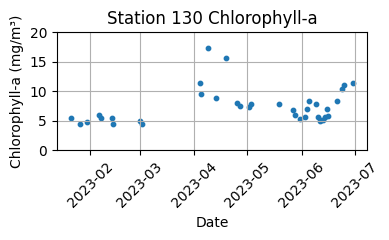

Retrieved Chl a for station 51, 181 points.
51: Requested (51.5317, 3.1828) → Retrieved (51.5469, 3.1823)


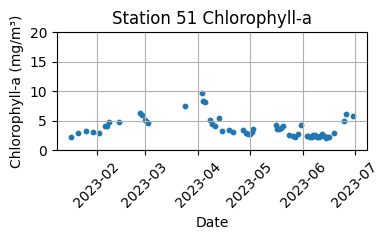

In [4]:
# Coordinate grids used by the THREDDS server
lat_array = np.linspace(89.98, -89.98, 17279)
lon_array = np.linspace(-180, 180, 34559)

station_chla_series = {}

# Get the full time coordinate as datetime array
ds_time = xr.open_dataset('https://rsg.pml.ac.uk/thredds/dodsC/CCI_ALL-v6.0-1km-DAILY?time')
time_values = pd.to_datetime(ds_time['time'].values)

# Find the indices for my sampling period
start_date = pd.Timestamp("2023-01-01")
end_date = pd.Timestamp("2023-06-30")
time_start = np.searchsorted(time_values, start_date)
time_end = np.searchsorted(time_values, end_date)

print(f"Limiting query to indices {time_start} to {time_end} ({time_values[time_start]} to {time_values[time_end]})")

for name, coords in stations.items():
    lat_idx = np.abs(lat_array - coords['lat']).argmin()
    lon_idx = np.abs(lon_array - coords['lon']).argmin()

    url = (
        f'https://rsg.pml.ac.uk/thredds/dodsC/CCI_ALL-v6.0-1km-DAILY?'
        f'time[{time_start}:{time_end}],'
        f'chlor_a[{time_start}:{time_end}][{lat_idx}:{lat_idx}][{lon_idx}:{lon_idx}],'
        f'lat[{lat_idx}:{lat_idx}],'
        f'lon[{lon_idx}:{lon_idx}]'
    )

    try:
        ds = xr.open_dataset(url)
        chl_series = ds['chlor_a'][:, 0, 0].to_dataframe().reset_index()
        chl_series = chl_series[['time', 'chlor_a']]
        chl_series.columns = ['timestamp', 'chlor_a']


        station_chla_series[name] = chl_series
        print(f"Retrieved Chl a for station {name}, {len(chl_series)} points.")
        
        # Retrieve and log actual coordinates used by server
        actual_lat = ds['lat'].values.item()
        actual_lon = ds['lon'].values.item()
        print(f"{name}: Requested ({coords['lat']:.4f}, {coords['lon']:.4f}) → Retrieved ({actual_lat:.4f}, {actual_lon:.4f})")
        
        # Exploratory plot
        plt.figure(figsize=(4, 2.5))
        plt.scatter(chl_series['timestamp'], chl_series['chlor_a'], s=10)
        plt.title(f'Station {name} Chlorophyll-a')
        plt.xlabel('Date')
        # Rotate x axis labels for better readability
        plt.xticks(rotation=45)
        plt.ylabel('Chlorophyll-a (mg/m³)')
        # Y limit based on data range
        plt.ylim(0, 20)
        plt.grid()
        # Save figure
        plt.savefig(f'../figures/environmental/chla_station_{name}.png', dpi=1200)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Failed for station {name}: {e}")

/var/folders/sw/y59p6zb57zd9ntdpcr65r3q40000gn/T/ipykernel_28875/1058755200.py:46: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  rolling_std = rolling_std.fillna(method='bfill').fillna(method='ffill')


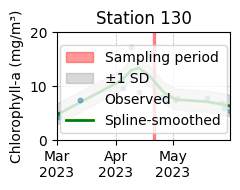

/var/folders/sw/y59p6zb57zd9ntdpcr65r3q40000gn/T/ipykernel_28875/1058755200.py:46: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  rolling_std = rolling_std.fillna(method='bfill').fillna(method='ffill')


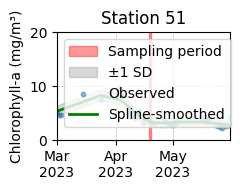

In [ ]:
shared_xlim = (pd.Timestamp("2023-03-01"), pd.Timestamp("2023-05-31"))

for name, df in station_chla_series.items():
    sampling_start, sampling_end = sampling_periods.get(name, (None, None))

    plot_smoothed_station_timeseries(
        df,
        value_col="chlor_a",
        station_name=f"Station {name}",
        ylabel="Chlorophyll-a (mg/m³)",
        spline_sensitivity_factor=10,
        ylim=(0, 20),
        xlim=shared_xlim,
        sampling_start=sampling_start,
        sampling_end=sampling_end,
        output_prefix="smoothed_chla"
    )